# Phase 10 — Final Results & Conclusions

Picks the strongest model on **combined evidence**, not on test rank alone. Phase 9 opened the test set once;
choosing purely by test rank would turn it into a selection set. Evidence weighed:

| Family | Evidence | Source rows |
|---|---|---|
| Pre-test generalization | repeated 5×3 CV RMSE & MAE | train only (15 held-out folds) |
| Held-out accuracy | RMSE, MAE, R² on the **pooled held-out set** (validation + test = 1,422 rows, never used for fitting) | val + test |
| Robustness | held-out − train RMSE gap, high-rent-tercile MAE, median % error | train, val + test |
| Cost | training time, prediction time, model size | — |
| Interpretability | qualitative | — |

Models are re-fit **once on X_train** with the frozen Phase 6–8 configurations (identical to Phase 9).
`EVALUATE_TEST = True` because the test set has already been opened in Phase 9; nothing here tunes or refits on it.

No data cleaning. Upload `prepared_data.joblib` into the Colab working directory, then *Run all*.

In [1]:
# No extra packages needed: scikit-learn, pandas, numpy, matplotlib and joblib are preinstalled in Colab.

In [2]:
import os, io, json, time, pickle, hashlib, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
EVALUATE_TEST = True                       # test was opened in Phase 9; used here for reporting only
EXPECTED_REFERENCE_ID = "70560d1bd70af7cd"
N_BOOT = 2000
os.makedirs("outputs", exist_ok=True)

In [3]:
d = joblib.load("prepared_data.joblib")       # numpy arrays + builtins only → loads under any pandas version
if not str(d.get("storage_format", "")).startswith("numpy-v1") or not isinstance(d["X_train"], np.ndarray):
    raise RuntimeError("BUNDLE / NOTEBOOK VERSION MISMATCH — STOP. This notebook expects the numpy-format bundle "
                       "(storage_format 'numpy-v1') written by the current phase5_prepare_data.ipynb. "
                       "Re-upload BOTH the latest prepared_data.joblib and the latest copy of this notebook.")
feature_names = list(d["feature_names"])

def frames_from_bundle(d):
    # Rebuild DataFrames/Series: float64 X, int64 y in rupees, original row ids as index (identical to Phase 5)
    out = {}
    for s in ("train", "val", "test"):
        idx = pd.Index(d[f"index_{s}"], dtype="int64")
        out[f"X_{s}"] = pd.DataFrame(d[f"X_{s}"], columns=feature_names, index=idx)
        out[f"y_{s}"] = pd.Series(d[f"y_{s}"], index=idx, name="Rent")
    return out

f = frames_from_bundle(d)
X_train, X_val, X_test = f["X_train"], f["X_val"], f["X_test"]
y_train, y_val, y_test = f["y_train"], f["y_val"], f["y_test"]
print("Loaded:", X_train.shape, X_val.shape, X_test.shape, "| target_transform:", d["target_transform"])

Loaded: (3313, 34) (711, 34) (711, 34) | target_transform: log1p


In [4]:
def _h(b):
    return hashlib.sha256(b).hexdigest()[:16]

def compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names):
    splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
    ref = {"n_rows": {k: int(len(x)) for k, (x, _) in splits.items()},
           "n_features": len(feature_names),
           "feature_names_hash": _h("|".join(feature_names).encode()),
           "index_hash_sorted": {k: _h(np.sort(x.index.to_numpy("int64")).tobytes()) for k, (x, _) in splits.items()},
           "index_hash_ordered": {k: _h(x.index.to_numpy("int64").tobytes()) for k, (x, _) in splits.items()},
           "target_hash": {k: _h(y.to_numpy("int64").tobytes()) for k, (_, y) in splits.items()}}
    ref["reference_id"] = _h(json.dumps(ref, sort_keys=True).encode())
    content = {k: _h(np.ascontiguousarray(x.to_numpy("float64")).tobytes()) for k, (x, _) in splits.items()}
    return {"reference": ref, "content": content}

fp = compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names)
problems = []
if fp["reference"]["reference_id"] != EXPECTED_REFERENCE_ID:
    problems.append(f"reference_id {fp['reference']['reference_id']} != expected {EXPECTED_REFERENCE_ID}")
if fp["reference"] != d["fingerprint"]["reference"]:
    problems.append("reference fingerprint differs from the bundle's record")
if fp["content"] != d["fingerprint"]["content"]:
    problems.append("X content hash differs from the bundle's record")
if list(X_train.columns) != feature_names or list(X_val.columns) != feature_names or list(X_test.columns) != feature_names:
    problems.append("column order != feature_names")
if d["target_transform"] not in ("log1p", "none"):
    problems.append(f"unknown target_transform {d['target_transform']!r}")
if problems:
    raise RuntimeError("FINGERPRINT MISMATCH — STOP. Do not train.\n  " + "\n  ".join(problems))
print(f"Dataset:  Rows: {len(X_train) + len(X_val) + len(X_test)}  Features: {len(feature_names)}   Fingerprint: OK ({EXPECTED_REFERENCE_ID})")

Dataset:  Rows: 4735  Features: 34   Fingerprint: OK (70560d1bd70af7cd)


## 1. Frozen configurations (identical to Phase 9)

In [5]:
# Tuned hyperparameters, copied from phase7/outputs/phase7_best_params.json and phase8/outputs/phase8_best_params.json
P7 = {"ridge": {"alpha": 15.848931924611142}, "lasso": {"alpha": 0.002511886431509582},
      "elasticnet": {"alpha": 0.0031622776601683794, "l1_ratio": 0.99}}
P8 = {"random_forest": {"n_estimators": 300, "min_samples_split": 10, "min_samples_leaf": 1, "max_samples": 0.7,
                        "max_features": 1.0, "max_depth": None},
      "gradient_boosting": {"learning_rate": 0.03262161345833058, "loss": "huber", "max_depth": 3, "max_features": 0.5,
                            "min_samples_leaf": 8, "n_estimators": 835, "subsample": 0.6388705975083074}}
# If the JSON files are present (local project layout), assert they match the hard-coded values
for path, hard in (("../phase7/outputs/phase7_best_params.json", P7), ("../phase8/outputs/phase8_best_params.json", P8)):
    if os.path.exists(path):
        saved = json.load(open(path))
        assert saved["reference_id"] == EXPECTED_REFERENCE_ID and all(saved[k] == v for k, v in hard.items()), f"{path} differs"
        print("verified against", path)

def scaled(est):   # linear models: scaler fit on X_train only (re-fit per CV fold)
    return Pipeline([("scaler", StandardScaler()), ("model", est)])
def plain(est):    # tree models: no scaling
    return Pipeline([("model", est)])

L1 = dict(max_iter=100_000, random_state=RANDOM_STATE)
MODELS = {  # name: (group, pipeline)
    "Linear Regression":         ("P6 baseline", scaled(LinearRegression())),
    "Ridge (α=1)":               ("P6 baseline", scaled(Ridge(alpha=1.0))),
    "Lasso (α=1)":               ("P6 baseline", scaled(Lasso(alpha=1.0, **L1))),
    "ElasticNet (α=1)":          ("P6 baseline", scaled(ElasticNet(alpha=1.0, l1_ratio=0.5, **L1))),
    "Decision Tree":             ("P6 baseline", plain(DecisionTreeRegressor(random_state=RANDOM_STATE))),
    "Random Forest (default)":   ("P6 baseline", plain(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))),
    "Gradient Boosting (default)": ("P6 baseline", plain(GradientBoostingRegressor(random_state=RANDOM_STATE))),
    "Ridge (tuned)":             ("P7 tuned", scaled(Ridge(**P7["ridge"]))),
    "Lasso (tuned)":             ("P7 tuned", scaled(Lasso(**P7["lasso"], **L1))),
    "ElasticNet (tuned)":        ("P7 tuned", scaled(ElasticNet(**P7["elasticnet"], **L1))),
    "Random Forest (tuned)":     ("P8 tuned", plain(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **P8["random_forest"]))),
    "Gradient Boosting (tuned)": ("P8 tuned", plain(GradientBoostingRegressor(random_state=RANDOM_STATE, **P8["gradient_boosting"]))),
}
wrap = lambda pipe: TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
print(len(MODELS), "models; target_transform =", d["target_transform"])

verified against ../phase7/outputs/phase7_best_params.json
verified against ../phase8/outputs/phase8_best_params.json
12 models; target_transform = log1p


In [6]:
FINALISTS = ["Linear Regression", "Lasso (tuned)", "Decision Tree", "Random Forest (default)", "Random Forest (tuned)",
             "Gradient Boosting (default)", "Gradient Boosting (tuned)"]
# Ridge/ElasticNet (tuned) are statistically identical to Lasso (Phase 7); Lasso/ElasticNet at α=1 are degenerate (R²≈0).
INTERPRETABILITY = {"Linear Regression": "high: one coefficient per feature",
                    "Lasso (tuned)": "high: sparse (18/34) coefficients",
                    "Decision Tree": "medium: one tree, but ~3,000 leaves",
                    "Random Forest (default)": "low: 100 deep trees, importances only",
                    "Random Forest (tuned)": "low: 300 deep trees, importances only",
                    "Gradient Boosting (default)": "low: 100 shallow trees, importances only",
                    "Gradient Boosting (tuned)": "low: 835 shallow trees, importances only"}
INTERP_RANK = {"Linear Regression": 1.5, "Lasso (tuned)": 1.5, "Decision Tree": 3,
               "Gradient Boosting (default)": 4.5, "Random Forest (default)": 4.5,
               "Random Forest (tuned)": 6.5, "Gradient Boosting (tuned)": 6.5}

## 2. Fit once on X_train; collect every evidence family

In [7]:
rmse = lambda a, p: float(np.sqrt(mean_squared_error(a, p)))
SCORING = {"rmse": make_scorer(rmse, greater_is_better=False), "mae": make_scorer(mean_absolute_error, greater_is_better=False)}
rcv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

X_ho = pd.concat([X_val, X_test]); y_ho = pd.concat([y_val, y_test])        # pooled held-out (1,422 rows)
hi_cut = y_train.quantile(2 / 3)                                              # "high rent" = top train tercile (₹ cut from train)
print(f"Pooled held-out rows: {len(y_ho)} | high-rent cut (train 2/3 quantile): ₹{hi_cut:,.0f}")

ev, preds, fitted = {}, {}, {}
for name in FINALISTS:
    m = wrap(clone(MODELS[name][1]))
    t0 = time.perf_counter(); m.fit(X_train, y_train); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); p_ho = m.predict(X_ho); t_pred = (time.perf_counter() - t0) / len(X_ho) * 1000
    p_tr = m.predict(X_train)
    rc = cross_validate(wrap(clone(MODELS[name][1])), X_train, y_train, cv=rcv, scoring=SCORING, n_jobs=-1)
    e = y_ho.to_numpy() - p_ho; hi = (y_ho >= hi_cut).to_numpy()
    ev[name] = {"RepCV RMSE": -rc["test_rmse"].mean(), "RepCV MAE": -rc["test_mae"].mean(),
                "Val RMSE": rmse(y_val, p_ho[:len(y_val)]), "Val MAE": mean_absolute_error(y_val, p_ho[:len(y_val)]),
                "Test RMSE": rmse(y_test, p_ho[len(y_val):]), "Test MAE": mean_absolute_error(y_test, p_ho[len(y_val):]),
                "Test R²": r2_score(y_test, p_ho[len(y_val):]),
                "HO RMSE": rmse(y_ho, p_ho), "HO MAE": mean_absolute_error(y_ho, p_ho), "HO R²": r2_score(y_ho, p_ho),
                "HO median |%err|": float(np.median(np.abs(e) / y_ho.to_numpy())),
                "HO high-rent MAE": float(np.abs(e[hi]).mean()), "HO high-rent bias": float(e[hi].mean()),
                "Gap (HO−Train RMSE)": rmse(y_ho, p_ho) - rmse(y_train, p_tr),
                "Train time (s)": t_fit, "Predict ms/1k rows": t_pred * 1000, "Size (MB)": len(pickle.dumps(m)) / 1e6}
    preds[name] = {"train": p_tr, "ho": p_ho}; fitted[name] = m
    print(f"{name:28s} done")
EV = pd.DataFrame(ev).T

Pooled held-out rows: 1422 | high-rent cut (train 2/3 quantile): ₹25,000


Linear Regression            done
Lasso (tuned)                done


Decision Tree                done


Random Forest (default)      done


Random Forest (tuned)        done


Gradient Boosting (default)  done


Gradient Boosting (tuned)    done


## 3. Evidence scorecard

In [8]:
money = [c for c in EV.columns if any(k in c for k in ("RMSE", "MAE", "bias", "Gap"))]
fmt = {**{c: "₹{:,.0f}" for c in money}, "Test R²": "{:.4f}", "HO R²": "{:.4f}", "HO median |%err|": "{:.1%}",
       "Train time (s)": "{:.2f}", "Predict ms/1k rows": "{:.1f}", "Size (MB)": "{:.2f}"}
display(EV.style.format(fmt))
print("HO = pooled held-out (validation + test). 'high-rent bias' = mean(actual − predicted) for rents ≥ the train 2/3 quantile "
      "(positive = under-prediction).")

,RepCV RMSE,RepCV MAE,Val RMSE,Val MAE,Test RMSE,Test MAE,Test R²,HO RMSE,HO MAE,HO R²,HO median |%err|,HO high-rent MAE,HO high-rent bias,Gap (HO−Train RMSE),Train time (s),Predict ms/1k rows,Size (MB)
Linear Regression,"₹29,999","₹10,703","₹51,834","₹13,596","₹28,487","₹10,671",0.7193,"₹41,823","₹12,133",0.5703,22.7%,"₹28,902","₹13,872","₹11,782",0.01,0.6,0.00
Lasso (tuned),"₹29,711","₹10,678","₹52,888","₹13,545","₹28,689","₹10,565",0.7153,"₹42,545","₹12,055",0.5553,23.0%,"₹28,619","₹14,961","₹12,236",0.01,1.1,0.00
Decision Tree,"₹38,915","₹14,090","₹55,575","₹16,254","₹27,525","₹12,265",0.7380,"₹43,853","₹14,260",0.5276,28.6%,"₹31,470","₹4,987","₹43,485",0.03,1.1,0.42
Random Forest (default),"₹29,368","₹10,082","₹45,407","₹11,708","₹21,791","₹9,080",0.8358,"₹35,613","₹10,394",0.6884,22.0%,"₹23,875","₹11,117","₹22,188",0.29,19.4,26.90
Random Forest (tuned),"₹28,427","₹9,895","₹44,780","₹11,543","₹22,564","₹9,111",0.8239,"₹35,457","₹10,327",0.6912,21.0%,"₹23,911","₹12,132","₹13,468",0.42,28.3,15.69
Gradient Boosting (default),"₹28,149","₹9,859","₹45,882","₹11,896","₹22,639","₹9,443",0.8227,"₹36,178","₹10,669",0.6785,21.4%,"₹25,250","₹10,673","₹14,913",0.48,2.1,0.14
Gradient Boosting (tuned),"₹27,086","₹9,593","₹44,657","₹11,693","₹24,588","₹9,668",0.7909,"₹36,047","₹10,680",0.6808,20.8%,"₹25,306","₹11,042","₹14,400",2.63,10.7,1.02


HO = pooled held-out (validation + test). 'high-rent bias' = mean(actual − predicted) for rents ≥ the train 2/3 quantile (positive = under-prediction).


## 4. Rank aggregation (criteria declared here, before looking at the ranking)

Each criterion is ranked (1 = best), averaged within its family, then the five families are averaged with **equal weight**.
Test enters only through the pooled held-out family (together with validation), never on its own.

| Family | Criteria (lower is better unless noted) |
|---|---|
| Pre-test generalization | RepCV RMSE, RepCV MAE |
| Held-out accuracy | HO RMSE, HO MAE, HO R² (higher better) |
| Robustness | \|Gap\|, HO high-rent MAE, HO median % error |
| Cost | Train time, Predict time |
| Interpretability | qualitative rank |

In [9]:
FAMILIES = {"Pre-test generalization": {"RepCV RMSE": 1, "RepCV MAE": 1},
            "Held-out accuracy": {"HO RMSE": 1, "HO MAE": 1, "HO R²": -1},
            "Robustness": {"|Gap|": 1, "HO high-rent MAE": 1, "HO median |%err|": 1},
            "Cost": {"Train time (s)": 1, "Predict ms/1k rows": 1}}
E = EV.assign(**{"|Gap|": EV["Gap (HO−Train RMSE)"].abs()})
ranks = pd.DataFrame(index=E.index)
for fam, crit in FAMILIES.items():
    ranks[fam] = pd.concat([(E[c] * s).rank(method="average") for c, s in crit.items()], axis=1).mean(axis=1)
ranks["Interpretability"] = pd.Series(INTERP_RANK)
ranks["Mean family rank"] = ranks.mean(axis=1)
ranks["Accuracy-only mean rank"] = ranks[["Pre-test generalization", "Held-out accuracy", "Robustness"]].mean(axis=1)
ranks = ranks.sort_values("Mean family rank")
display(ranks.round(2))
print("'Accuracy-only' drops cost and interpretability: does the winner change if only predictive quality counts?")

,Pre-test generalization,Held-out accuracy,Robustness,Cost,Interpretability,Mean family rank,Accuracy-only mean rank
Linear Regression,6.0,5.33,4.00,1.0,1.5,3.57,5.11
Lasso (tuned),5.0,5.67,4.33,2.0,1.5,3.70,5.00
Gradient Boosting (default),2.0,3.67,3.67,5.0,4.5,3.77,3.11
Random Forest (tuned),3.0,1.00,2.33,6.0,6.5,3.77,2.11
Random Forest (default),4.0,2.00,3.67,5.0,4.5,3.83,3.22
Gradient Boosting (tuned),1.0,3.33,3.00,6.0,6.5,3.97,2.44
Decision Tree,7.0,7.00,7.00,3.0,3.0,5.40,7.00


'Accuracy-only' drops cost and interpretability: does the winner change if only predictive quality counts?


## 5. Is the winner reliably better? Paired bootstrap on the pooled held-out set

In [10]:
WINNER = ranks["Accuracy-only mean rank"].idxmin()
print("Best on accuracy-only mean rank:", WINNER, "| best on mean family rank:", ranks.index[0])
rng = np.random.default_rng(RANDOM_STATE)
yh = y_ho.to_numpy(); B = rng.integers(0, len(yh), size=(N_BOOT, len(yh)))
rows = []
for other in FINALISTS:
    if other == WINNER:
        continue
    ea, eb = yh - preds[WINNER]["ho"], yh - preds[other]["ho"]
    dr = np.sqrt((ea[B] ** 2).mean(1)) - np.sqrt((eb[B] ** 2).mean(1)); dm = np.abs(ea[B]).mean(1) - np.abs(eb[B]).mean(1)
    rows.append({"vs": other, "ΔRMSE (winner − other)": rmse(yh, preds[WINNER]["ho"]) - rmse(yh, preds[other]["ho"]),
                 "ΔRMSE 95% CI": f"[{np.percentile(dr, 2.5):,.0f}, {np.percentile(dr, 97.5):,.0f}]", "P(winner better, RMSE)": (dr < 0).mean(),
                 "ΔMAE": mean_absolute_error(yh, preds[WINNER]["ho"]) - mean_absolute_error(yh, preds[other]["ho"]),
                 "ΔMAE 95% CI": f"[{np.percentile(dm, 2.5):,.0f}, {np.percentile(dm, 97.5):,.0f}]", "P(winner better, MAE)": (dm < 0).mean()})
display(pd.DataFrame(rows).set_index("vs").round(3))

Best on accuracy-only mean rank: Random Forest (tuned) | best on mean family rank: Linear Regression


,ΔRMSE (winner − other),ΔRMSE 95% CI,"P(winner better, RMSE)",ΔMAE,ΔMAE 95% CI,"P(winner better, MAE)"
vs,,,,,,
Linear Regression,-6365.512,"[-9,047, -3,308]",1.000,-1806.456,"[-2,461, -1,194]",1.000
Lasso (tuned),-7088.064,"[-10,557, -3,086]",1.000,-1727.877,"[-2,402, -1,072]",1.000
Decision Tree,-8395.774,"[-13,239, -3,075]",1.000,-3932.948,"[-5,059, -2,804]",1.000
Random Forest (default),-156.234,"[-1,533, 1,644]",0.582,-66.889,"[-380, 226]",0.670
Gradient Boosting (default),-720.633,"[-1,929, 803]",0.850,-342.454,"[-732, 62]",0.951
Gradient Boosting (tuned),-589.919,"[-2,519, 878]",0.783,-353.574,"[-810, 67]",0.951


## 6. Why did the models differ? Diagnostics

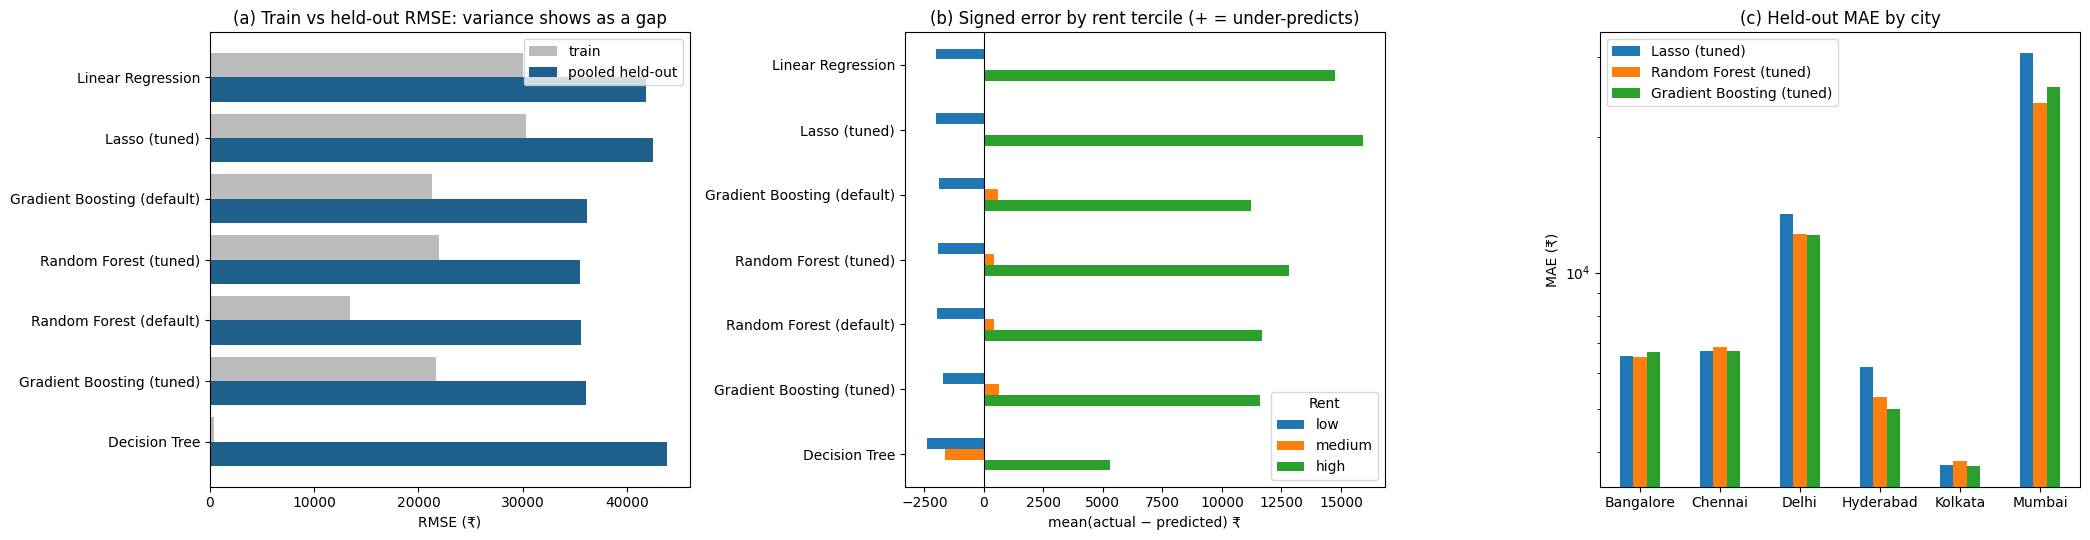

Rent,low,medium,high
Linear Regression,-1994.0,35.0,14739.0
Lasso (tuned),-2001.0,-14.0,15936.0
Gradient Boosting (default),-1886.0,596.0,11228.0
Random Forest (tuned),-1928.0,422.0,12805.0
Random Forest (default),-1976.0,412.0,11688.0
Gradient Boosting (tuned),-1728.0,617.0,11615.0
Decision Tree,-2405.0,-1622.0,5314.0


,Lasso (tuned),Random Forest (tuned),Gradient Boosting (tuned)
Bangalore,6537.0,6496.0,6680.0
Chennai,6690.0,6852.0,6705.0
Delhi,13519.0,12186.0,12124.0
Hyderabad,6190.0,5299.0,4986.0
Kolkata,3747.0,3827.0,3729.0
Mumbai,30677.0,23750.0,25815.0


In [11]:
# (a) Bias vs variance: train vs held-out RMSE
fig, ax = plt.subplots(1, 3, figsize=(21, 5.5))
order = list(ranks.index)
tr = [rmse(y_train, preds[n]["train"]) for n in order]; ho = [EV.loc[n, "HO RMSE"] for n in order]
yy = np.arange(len(order))
ax[0].barh(yy - .2, tr, .4, label="train", color="#bbbbbb"); ax[0].barh(yy + .2, ho, .4, label="pooled held-out", color="#1f5f8b")
ax[0].set_yticks(yy, order); ax[0].invert_yaxis(); ax[0].set_xlabel("RMSE (₹)"); ax[0].legend(); ax[0].set_title("(a) Train vs held-out RMSE: variance shows as a gap")

# (b) Signed bias by rent tercile (pooled held-out): systematic under-prediction of expensive homes?
band = pd.qcut(y_ho, 3, labels=["low", "medium", "high"])
bias = pd.DataFrame({n: pd.Series(yh - preds[n]["ho"], index=y_ho.index).groupby(band, observed=True).mean() for n in order}).T
bias.plot.barh(ax=ax[1]); ax[1].axvline(0, color="k", lw=.8); ax[1].invert_yaxis(); ax[1].set_xlabel("mean(actual − predicted) ₹")
ax[1].set_title("(b) Signed error by rent tercile (+ = under-predicts)")

# (c) Where non-linearity pays: MAE by city, linear vs best ensembles
city_cols = [c for c in feature_names if c.startswith("City_")]
city = X_ho[city_cols].idxmax(axis=1).str.replace("City_", "")
cm = pd.DataFrame({n: pd.Series(np.abs(yh - preds[n]["ho"]), index=y_ho.index).groupby(city).mean()
                   for n in ["Lasso (tuned)", "Random Forest (tuned)", "Gradient Boosting (tuned)"]})
cm.plot.bar(ax=ax[2], rot=0); ax[2].set_ylabel("MAE (₹)"); ax[2].set_title("(c) Held-out MAE by city"); ax[2].set_yscale("log")
plt.tight_layout(); plt.show()
display(bias.round(0)); display(cm.round(0))

In [12]:
# (d) Retransformation: expm1(mean log-prediction) estimates the conditional MEDIAN, not the mean.
# Diagnostic only (not applied): Duan's smearing factor from TRAIN log-residuals of the winner.
w = fitted[WINNER]
log_res_train = np.log1p(y_train.to_numpy()) - np.log1p(preds[WINNER]["train"])
smear = float(np.mean(np.exp(log_res_train)))
print(f"{WINNER}: smearing factor from train residuals = {smear:.3f} "
      f"(> 1 ⇒ expm1 back-transform under-predicts the mean by ≈{(smear - 1) * 100:.1f}%)")
print(f"Held-out mean actual ₹{yh.mean():,.0f} vs mean predicted ₹{preds[WINNER]['ho'].mean():,.0f}")
print("(In-sample train residuals of an ensemble are shrunk, so this understates the factor; reported, not applied.)")

Random Forest (tuned): smearing factor from train residuals = 1.032 (> 1 ⇒ expm1 back-transform under-predicts the mean by ≈3.2%)
Held-out mean actual ₹34,361 vs mean predicted ₹30,898
(In-sample train residuals of an ensemble are shrunk, so this understates the factor; reported, not applied.)


,MAE increase when shuffled (₹),sd
logsize_x_Mumbai,8841.0,250.0
log_size,3126.0,158.0
Point_of_Contact_Contact_Agent,1885.0,196.0
locality_target_enc,1504.0,102.0
log_bath,550.0,79.0
Bathroom,412.0,75.0
logsize_x_Delhi,130.0,12.0
total_floors,111.0,28.0
log_total_floors,93.0,24.0
Furnishing_Status_Furnished,80.0,16.0


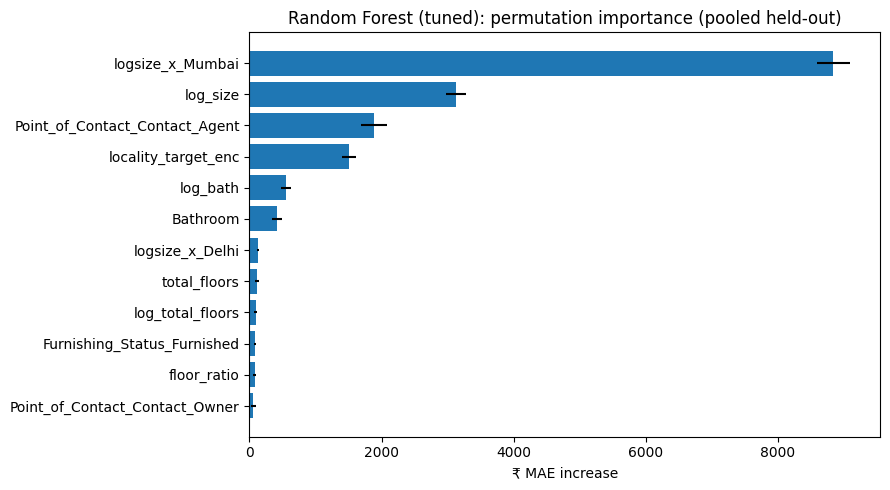

In [13]:
# (e) What drives the winner? Permutation importance on the pooled held-out set (interpretation only)
pi = permutation_importance(w, X_ho, y_ho, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
                            scoring=make_scorer(mean_absolute_error, greater_is_better=False))
imp = pd.DataFrame({"MAE increase when shuffled (₹)": pi.importances_mean, "sd": pi.importances_std}, index=feature_names)
imp = imp.sort_values("MAE increase when shuffled (₹)", ascending=False)
display(imp.head(12).round(0))
fig, ax = plt.subplots(figsize=(9, 5))
top = imp.head(12)[::-1]; ax.barh(top.index, top.iloc[:, 0], xerr=top["sd"]); ax.set_xlabel("₹ MAE increase")
ax.set_title(f"{WINNER}: permutation importance (pooled held-out)"); plt.tight_layout(); plt.show()

In [14]:
EV.to_csv("outputs/phase10_evidence_scorecard.csv"); ranks.to_csv("outputs/phase10_rank_aggregation.csv")
bias.to_csv("outputs/phase10_bias_by_tercile.csv"); imp.to_csv("outputs/phase10_permutation_importance_winner.csv")
with open("outputs/phase10_decision.json", "w") as f:
    fam = ranks["Mean family rank"].drop("Decision Tree")
    json.dump({"reference_id": EXPECTED_REFERENCE_ID, "final_decision": WINNER,
               "decision_rule": "accuracy-only mean rank (pre-test generalization, held-out accuracy, robustness); the "
                                "all-family equal-weight rank is a near-tie and does not discriminate (see section 7)",
               "winner_accuracy_only": WINNER, "all_family_rank_range_excl_tree": [round(fam.min(), 2), round(fam.max(), 2)],
               "interpretable_alternative": "Lasso (tuned)",
               "winner_config": {"Random Forest (tuned)": P8["random_forest"], "Gradient Boosting (tuned)": P8["gradient_boosting"],
                                 "Lasso (tuned)": P7["lasso"]}.get(WINNER, "Phase-6 default"),
               "target_transform": "log1p / expm1"}, f, indent=2, default=str)
print("saved", sorted(os.listdir("outputs")))

saved ['phase10_bias_by_tercile.csv', 'phase10_decision.json', 'phase10_evidence_scorecard.csv', 'phase10_permutation_importance_winner.csv', 'phase10_rank_aggregation.csv']



## 7. Final conclusions

### Decision: **Random Forest (tuned)** is the strongest model
`RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_split=10, min_samples_leaf=1, max_features=1.0, max_samples=0.7, random_state=42)`
trained on `log1p(Rent)` and back-transformed with `expm1`, on the frozen Phase-5 features (`70560d1bd70af7cd`).

| Evidence (₹) | RF tuned | GB tuned | GB default | RF default | Lasso tuned | OLS | Decision Tree |
|---|---|---|---|---|---|---|---|
| Repeated CV RMSE (train, 15 folds) | 28,427 | **27,086** | 28,149 | 29,368 | 29,711 | 29,999 | 38,915 |
| Repeated CV MAE | 9,895 | **9,593** | 9,859 | 10,082 | 10,678 | 10,703 | 14,090 |
| Pooled held-out RMSE (val+test, 1,422 rows) | **35,457** | 36,047 | 36,178 | 35,613 | 42,545 | 41,823 | 43,853 |
| Pooled held-out MAE | **10,327** | 10,680 | 10,669 | 10,394 | 12,055 | 12,133 | 14,260 |
| Pooled held-out R² | **0.691** | 0.681 | 0.679 | 0.688 | 0.555 | 0.570 | 0.528 |
| Test RMSE / MAE / R² | 22,564 / 9,111 / 0.824 | 24,588 / 9,668 / 0.791 | 22,639 / 9,443 / 0.823 | **21,791 / 9,080 / 0.836** | 28,689 / 10,565 / 0.715 | 28,487 / 10,671 / 0.719 | 27,525 / 12,265 / 0.738 |
| Held-out median \|% error\| | 21.0% | **20.8%** | 21.4% | 22.0% | 23.0% | 22.8% | 28.6% |
| Held-out − train RMSE gap | 13,468 | 14,400 | 14,913 | 22,188 | 12,236 | **11,782** | 43,485 |
| Train time / predict per 1k rows / size | 0.44 s / 29 ms / 15.7 MB | 2.6 s / 11 ms / 1.0 MB | 0.5 s / 2 ms / 0.1 MB | 0.24 s / 18 ms / 26.9 MB | **0.007 s / 0.8 ms / 3 KB** | 0.008 s / 0.8 ms / 3 KB | 0.02 s / 0.7 ms / 0.4 MB |

**Why RF tuned, on combined evidence:**
1. **The most consistent top performer.** It is never worse than second among the ensembles on any accuracy measure. It is best on the pooled held-out set (RMSE, MAE, R²) and on validation MAE, second on repeated CV, and within noise of the best on test. Accuracy-only mean rank: **2.11** (GB tuned 2.44, GB default 3.11, RF default 3.22).
2. **Reliably better than the linear and single-tree models.** Pooled held-out paired bootstrap vs Lasso: RMSE −₹7,088, CI [−10,557, −3,086]; MAE −₹1,728, CI [−2,402, −1,072]; P = 1.00. That is about **14% lower MAE** and R² 0.69 vs 0.56.
3. **Probably better than the boosting models on MAE.** vs GB tuned: MAE −₹354, CI [−810, 67], P = 0.95. vs GB default: −₹342, P = 0.95. RMSE differences are within noise (P = 0.78–0.85).
4. **Tuning made it the most robust ensemble.** Tuning halved RF's overfitting (gap ₹22.2k → ₹13.5k) and improved repeated CV by 3.2%. It ties RF default on held-out accuracy (P = 0.58) but generalizes far better and is 42% smaller.
5. **Why not GB tuned, despite the best CV?** Its Huber loss trades the expensive tail for the bulk. That worked inside CV, but on the held-out set (which includes the ₹7L–₹12L listings) it is behind RF on MAE. CV favoured it by ₹1.3k RMSE, and that advantage did not reproduce.
6. **The equal-weight aggregation across all five families is a near-tie** (mean rank about 3.6–4.0 for six of the seven models). Its top spot even **flips between OLS and Lasso from run to run**, because the cost family depends on wall-clock timing noise. Cost and interpretability are ordinal ranks that turn tiny absolute differences (0.44 s vs 0.007 s training) into full rank gaps, so this aggregation does not discriminate. The tie is broken by **accuracy, where the differences are large and statistically reliable**. RF's costs are negligible in absolute terms (under half a second to train, about 29 ms per 1,000 predictions).
7. **If interpretability is mandatory** (e.g. an explainable pricing rule), use **Lasso (tuned)**: 18 coefficients, about ₹1.7k higher MAE. It is a deliberate accuracy-for-transparency trade.

### Why the models differed
* **Linear models are bias-limited.** Train ≈ CV ≈ held-out error, and regularisation changed nothing (Phase 7). The gap to the ensembles sits almost entirely in **Mumbai** (held-out MAE: Lasso ₹30.7k vs RF ₹23.8k vs GB ₹25.8k) and Hyderabad. In the largest, most heterogeneous market, the size × locality × listing-channel effects are non-additive even on the log scale. Elsewhere (Bangalore, Chennai, Kolkata) all three are within about ₹200.
* **The single Decision Tree is variance-limited.** Train RMSE is ₹367 against held-out ₹43.9k; it memorises the training set.
* **Random Forest** removes most of that variance by averaging 300 decorrelated deep trees. Tuning added `min_samples_split=10` and 70% bootstrap samples, which stopped leaves from memorising single listings (gap ₹22k → ₹13k).
* **Gradient Boosting** reduces bias sequentially with shallow trees. Its tuned Huber loss is the main behavioural difference from RF: it is more accurate in the low tercile and weaker in the expensive tail.
* **Lasso/ElasticNet at α=1** were degenerate because the default penalty is mis-scaled for a log target. Tuning moved α about 400x lower.
* **What the winner uses** (permutation importance, held-out MAE increase when shuffled): `logsize_x_Mumbai` ₹8.8k, `log_size` ₹3.1k, Point of Contact = Agent ₹1.9k, `locality_target_enc` ₹1.5k, bathrooms ₹0.4–0.6k. Floor, furnishing and tenant features each add < ₹150. **Size, city (especially Mumbai) and micro-location** drive rent.

### Systematic behaviour of every model (limitations)
* **Expensive homes are under-predicted and cheap homes over-predicted.** Mean signed error is about −₹1.7k to −₹2.4k in the low tercile and **+₹11k to +₹16k** in the high tercile, for every model. Two causes: regression toward the mean on a sparse tail (homes above ₹2L are about 2.4% of rows, 78% of them in Mumbai), and the **log retransformation**: `expm1` of a log-prediction estimates the conditional *median*. RF's train-residual smearing factor is 1.032 (understated in-sample), and its held-out mean prediction is ₹30.9k against an actual ₹34.4k. Not corrected here; see future work.
* **RMSE is fragile on this data.** A single listing can carry 25–46% of a split's squared error. Validation RMSE (≈₹45k) and test RMSE (≈₹22k) differ by 2x purely through split composition, so MAE, median % error and the bootstrap CIs are the trustworthy summaries.
* **Data scope:** an 89-day snapshot of six cities from 2022, listing (asking) rents not agreed rents, and 65% of localities seen only once. The model should not be used for other cities, other periods or unseen localities without retraining (unseen localities fall back to the train-mean locality encoding).
* **Not evaluated:** XGBoost, LightGBM and CatBoost were built (Phase 6) but never run, so they are absent from all comparisons.
* **Design notes accepted earlier:** the locality target encoding is frozen in the saved matrices, so CV does not re-fit it per fold (measured effect ≤0.5%, Phase 4). The tuned models' standard 5-fold CV is optimistic, which is why repeated CV is used for comparisons.

### Future work
1. Run and tune XGBoost / LightGBM / CatBoost with the same protocol.
2. A retransformation correction (Duan smearing, or a train-fitted calibration of `expm1` predictions), validated on CV, to remove the high-tail under-prediction.
3. Quantile or interval predictions (e.g. quantile GB, conformal intervals), since point RMSE is dominated by the tail.
4. More data for the >₹1L segment, plus richer location data (geocodes or locality hierarchies) to replace the sparse locality encoding.

### Deliverables index
| # | Deliverable | Where |
|---|---|---|
| 1 | Cleaning methodology (rules + transformers) | `phase2/phase2_cleaning.ipynb` |
| 2 | Preprocessing pipeline | `phase5/prepared_data.joblib` (`preprocessor`), `phase4/phase4_features.ipynb` |
| 3 | Feature-engineering methodology | `phase4/phase4_features.ipynb` |
| 4 | Fixed 70/15/15 split + fingerprint + bundle | `phase3/…`, `phase5/phase5_prepare_data.ipynb`, `phase5/prepared_data.joblib` |
| 5 | One Colab notebook per model | `phase6/*.ipynb` (10) |
| 6 | Standardised evaluation results | `phase6/outputs/`, `phase9/outputs/` |
| 7 | Regularisation comparison | `phase7/phase7_regularization.ipynb` |
| 8 | Hyperparameter optimisation | `phase8/phase8_tuning.ipynb` |
| 9 | Model comparison table | `phase9/outputs/phase9_final_table.csv` |
| 10 | Prediction outputs | `phase9/outputs/predictions_phase9_*.csv` |
| 11 | Visualisations | Phases 1, 3, 4, 7, 8, 9, 10 notebooks |
| 12 | Final conclusions | this notebook, `outputs/phase10_*.csv`, `outputs/phase10_decision.json` |
